In [1]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
import scienceplots
from scipy.signal import find_peaks
from scipy.signal import hilbert
from scipy.optimize import curve_fit
from scipy.signal import savgol_filter
from scipy.fft import fft, fftfreq, fftshift, ifft, ifftshift
import math
from scipy import integrate
import pandas as pd
from statsmodels.nonparametric.smoothers_lowess import lowess
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from whittaker_eilers import WhittakerSmoother
from scipy.optimize import curve_fit

plt.style.use(["science", "no-latex", "grid"])
plt.rcParams.update({'font.size': 12})
plt.rcParams["text.latex.preamble"] = r"\usepackage{amsmath} \usepackage{amssymb} \usepackage{siunitx}"
plt.rcParams["figure.figsize"] = (14, 7) 

# %matplotlib widget
%matplotlib inline

In [2]:
filename = 'data/july_data/01473_S21_4to5_10dBattprobe_pumpontopMLOG_7.533e-08_edelay_2.32V_11.92GHz_9.0_dBm_pump.hdf5'
file = h5py.File(filename, 'r')
pump_freq = file['Parameters']['EQUIPMENT_PARAMETERS']['pump_freq'][()]
bias_current = file['Parameters']['EQUIPMENT_PARAMETERS']['ibias_on'][()]
pump_power = file['Parameters']['EQUIPMENT_PARAMETERS']['pump_power'][()]
print(bias_current, pump_power, pump_freq)

file['Parameters']['PHYSICAL_PARAMETERS']['Description'][()]

True 9.0 11920000000.0


b'S21_4to5_10dBattprobe_pumpontopMLOG_7.533e-08_edelay_2.32V_11.92GHz_9.0_dBm_pump'

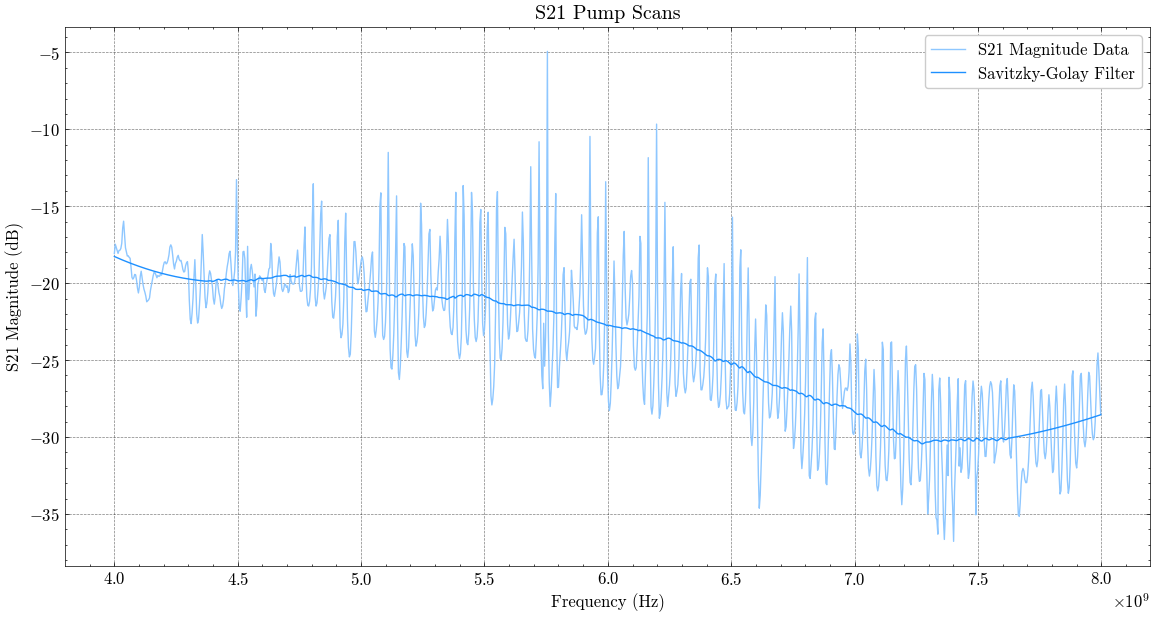

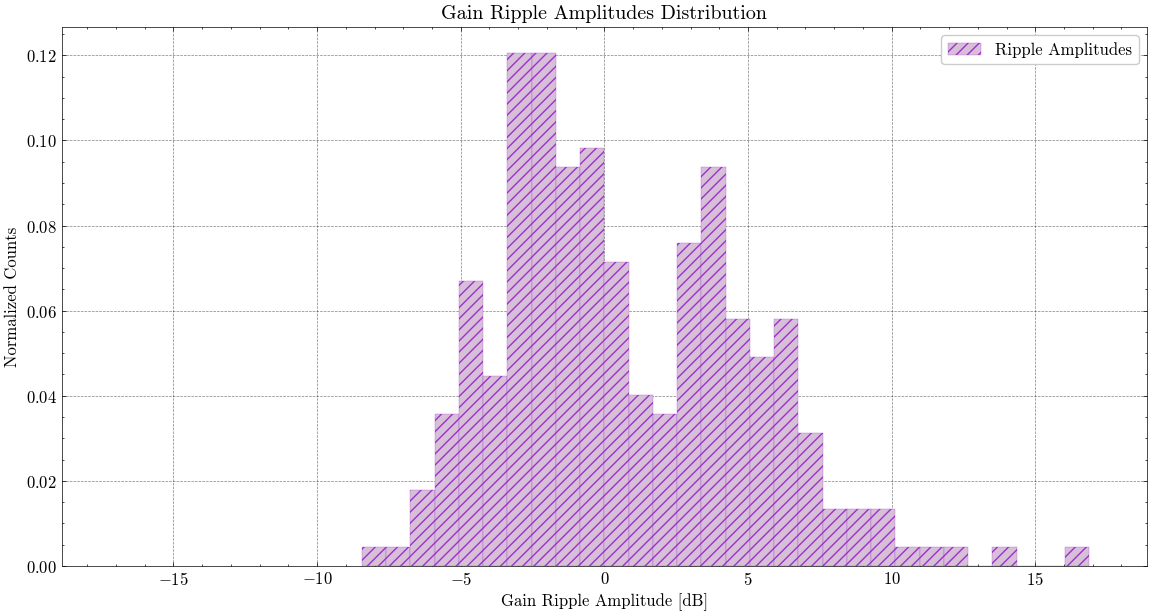

Mean of Gain Ripple Amplitudes:  0.761120939926018
Standard Deviation of Gain Ripple Amplitudes:  4.228236913582366


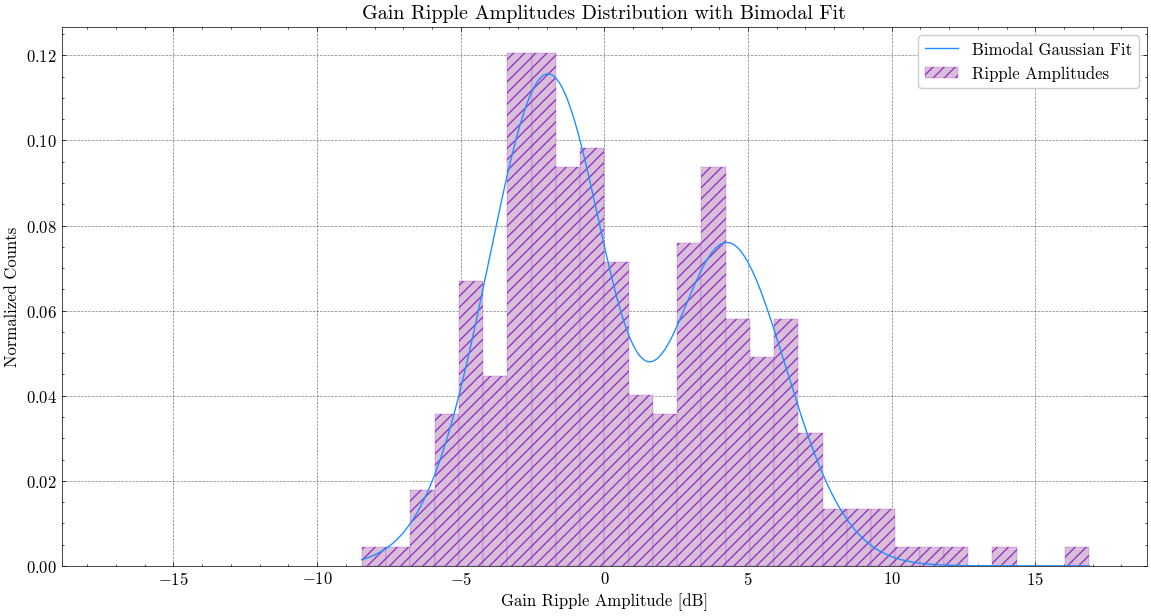

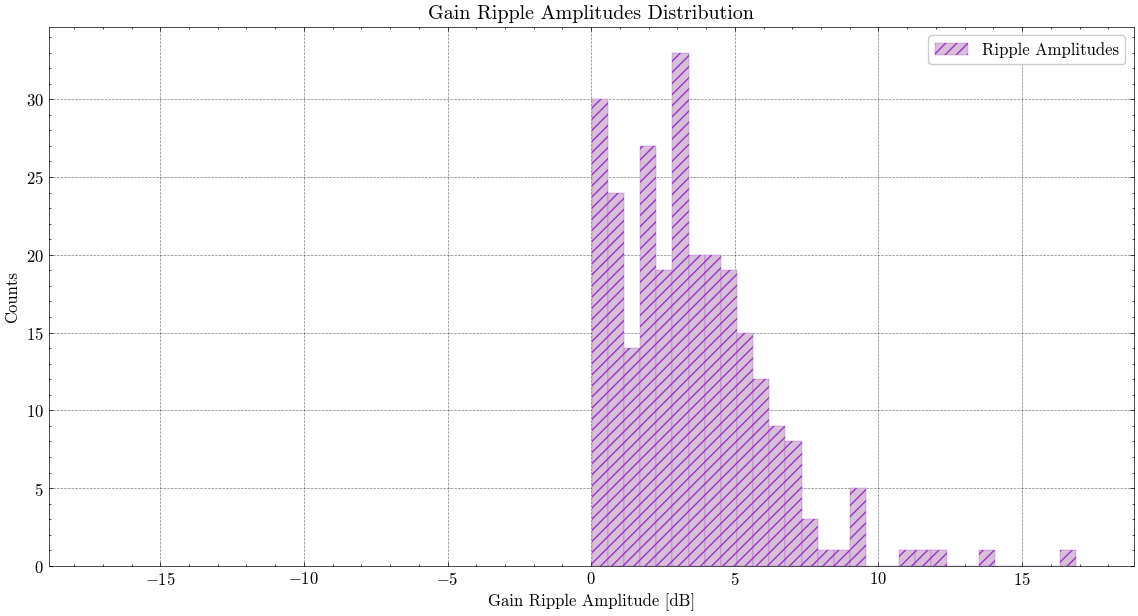

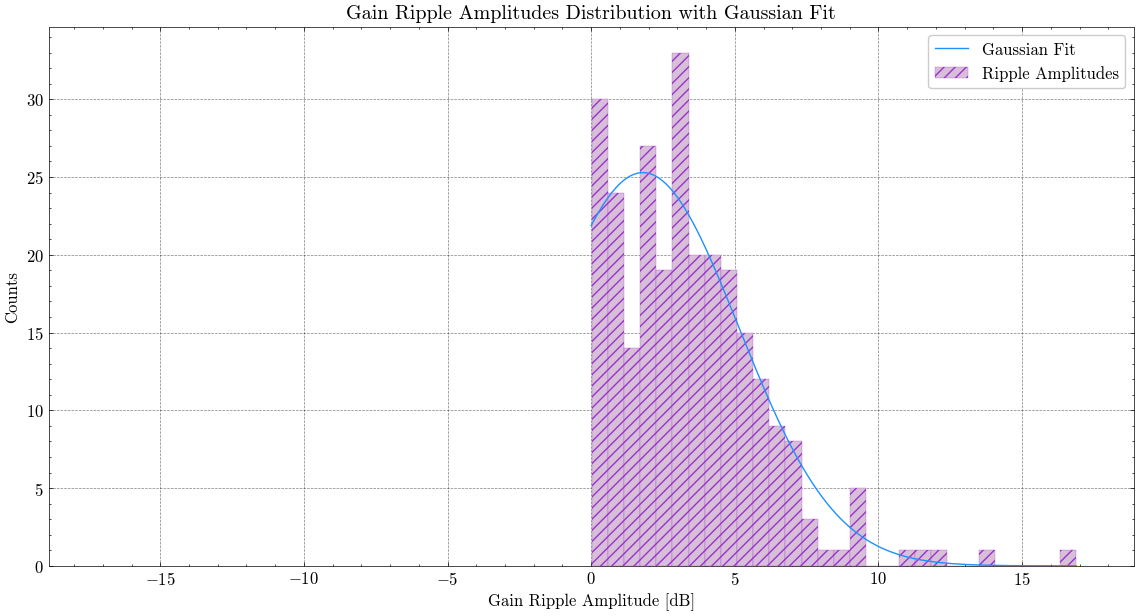

[ 48.96229603   1.00527003   2.53336651 -48.91046327   1.00704031
   2.5281749 ]
[25.28072702  1.79813833  3.343602  ]


[np.float64(0.761120939926018), np.float64(4.228236913582366)]

In [3]:
def gaussian(x, amplitude, mean, stddev):
    return amplitude * np.exp(-((x - mean)**2 / (2 * stddev**2)))

def bimodal(x, amp1, mean1, stddev1, amp2, mean2, stddev2):
    return (gaussian(x, amp1, mean1, stddev1) + gaussian(x, amp2, mean2, stddev2))

def poisson(x, amplitude, mean):
    return amplitude * ((mean**x) * np.exp(-mean)) / math.factorial(x)

def find_ripples(filename, csv=False, start_band=4000000000.0, stop_band=8000000000.0):
    ''' 
    #################################################################
    ### This function takes the file and attempts to find the     ###
    ### average amplitudes of the gain ripples that we see        ###
    ### within our data. By using scipy's signal package we       ###
    ### can find the peaks and troughs in the data to determine   ###
    ### the amplitudes. Furthermore, these peak and trough        ###
    ### amplitudes are compared against a smoothed/filtered       ###  
    ### dataset to give us a better handle on the gain ripples.   ###
    ### An array of the ampliudes of the gain ripples is returned.###  
    #################################################################
    '''
    
    if (csv == False): 
        file = h5py.File(filename, 'r')
        freq_start = file['Parameters']['VNA_PARAMETERS']['freq_start'][0]
        freq_stop = file['Parameters']['VNA_PARAMETERS']['freq_stop'][0]
        probe_pts = file['Parameters']['VNA_PARAMETERS']['probe_pts'][()]
    
        freqs = np.linspace(freq_start, freq_stop, probe_pts)
        s21 = np.asarray(file['sweep_dataframe']).flatten()    
    else:
        df = pd.read_csv(filename, header=None)
        freqs = df[0].to_numpy()
        s21 = df[1].to_numpy()
        
    mask = (freqs >= start_band) & (freqs <= stop_band)
    freqs_window = freqs[mask]
    s21_window = s21[mask]
    
    # Applying a Rolling Average to the Data
    df = pd.DataFrame({'Frequency': freqs_window, 'Magnitude': s21_window})
    df.to_csv('gain_ripples_data.csv')
    s21_ravg = (df.Magnitude.rolling(250).mean()).to_numpy()
    
    # Applying the Savitzky-Golay Smoothing Function
    s21_sg = savgol_filter(s21_window, window_length=200, polyorder=2)
    
    # Applying the Whittaker Eilers Smoothing Function
    smoother = WhittakerSmoother(lmbda=2000, order=2, data_length=len(s21_window))
    s21_we = smoother.smooth(s21_window) 
    
    peaks, _ = find_peaks(s21_window, prominence=0.0001)
    troughs, _ = find_peaks(-s21_window, prominence=0.0001)
    
    plt.plot(freqs_window, s21_window, label='S21 Magnitude Data', color='#8ec7ff')
    # plt.plot(freqs_window, s21_ravg, label='Rolling Average', color='#1b81e5')
    plt.plot(freqs_window, s21_sg, label='Savitzky-Golay Filter', color='#1e90ff')
    # plt.plot(freqs_window, s21_we, label='Whittaker Eilers Smoother', color='r')
    # plt.plot(freqs_window[peaks], s21_window[peaks], 'o', label='Peaks', markersize=2.5, color='firebrick')
    # plt.plot(freqs_window[troughs], s21_window[troughs], 'o', label='Troughs', markersize=2.5, color='forestgreen')
    plt.title('S21 Pump Scans')
    plt.xlabel('Frequency (Hz)')
    plt.ylabel('S21 Magnitude (dB)')
    # plt.xlim(4e9, 4.15e9)
    plt.legend()
    plt.show()  
    
    ripple_amplitudes = []
    for i in range(0, len(peaks)):
        ripple_amplitudes.append(s21_window[peaks[i]] - s21_sg[peaks[i]])
    
    for i in range(0, len(troughs)):
        ripple_amplitudes.append(s21_window[troughs[i]] - s21_sg[troughs[i]])
    
    return ripple_amplitudes

def ripple_hist(ripple_amplitudes):
    '''
    ########################################################
    ### This function takes the gain ripple amplitudes   ###
    ### that we calculated earlier within a dataset and  ###
    ### creates a normalized histogram to visualize the  ###
    ### distribution. Also computes the average and the  ###
    ### standard deviation of the gain ripple amplitudes.###
    ########################################################
    '''
    
    range = 0
    if (abs(np.max(ripple_amplitudes))) >= (abs(np.min(ripple_amplitudes))):
        range = abs(np.max(ripple_amplitudes))
    else:
        range = abs(np.min(ripple_amplitudes))
    
    hist_counts, bin_edges, _ = plt.hist(ripple_amplitudes, bins=30, density=True, color='thistle', 
                                         edgecolor='darkorchid', hatch='///', linewidth=0.2, label='Ripple Amplitudes')
    plt.xlabel('Gain Ripple Amplitude [dB]')
    plt.ylabel('Normalized Counts')
    plt.title('Gain Ripple Amplitudes Distribution')
    plt.xlim((-1*(range + 2)), (range + 2))
    plt.legend()
    plt.show()
    
    print("Mean of Gain Ripple Amplitudes: ", np.mean(ripple_amplitudes))
    print("Standard Deviation of Gain Ripple Amplitudes: ", np.std(ripple_amplitudes))
    
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    init = [0, 0.5, 1, 0, 0.5, 1]
    popt, pcov = curve_fit(bimodal, bin_centers, hist_counts, p0=init)
    
    a1, m1, s1, a2, m2, s2 = popt
    x_fit = np.linspace(min(ripple_amplitudes), max(ripple_amplitudes), 10000)
    y_fit = bimodal(x_fit, a1, m1, s1, a2, m2, s2)
    
    plt.plot(x_fit, y_fit, color='dodgerblue', label='Bimodal Gaussian Fit')
    plt.hist(ripple_amplitudes, bins=30, density=True, color='thistle', 
             edgecolor='darkorchid', hatch='///', linewidth=0.2, label='Ripple Amplitudes')
    plt.xlabel('Gain Ripple Amplitude [dB]')
    plt.ylabel('Normalized Counts')
    plt.title('Gain Ripple Amplitudes Distribution with Bimodal Fit')
    plt.xlim((-1*(range + 2)), (range + 2))
    plt.legend()
    plt.show()
    
    hist_countsA, bin_edgesA, _ = plt.hist(np.abs(ripple_amplitudes), bins=30, density=False, color='thistle', 
                                          edgecolor='darkorchid', hatch='///', linewidth=0.2, label='Ripple Amplitudes')
    plt.xlabel('Gain Ripple Amplitude [dB]')
    plt.ylabel('Counts')
    plt.title('Gain Ripple Amplitudes Distribution')
    plt.xlim((-1*(range + 2)), (range + 2))
    plt.legend()
    plt.show()
    
    bin_centersA = (bin_edgesA[:-1] + bin_edgesA[1:]) / 2
    initA = [0, 0.5, 1]
    poptA, pcovA = curve_fit(gaussian, bin_centersA, hist_countsA, p0=initA)
    aA, mA, sA = poptA
    x_fitA = np.linspace(0, max(np.abs(ripple_amplitudes)), 10000)
    y_fitA = gaussian(x_fitA, aA, mA, sA)   
    
    plt.plot(x_fitA, y_fitA, color='dodgerblue', label='Gaussian Fit')
    plt.hist(np.abs(ripple_amplitudes), bins=30, density=False, color='thistle', 
             edgecolor='darkorchid', hatch='///', linewidth=0.2, label='Ripple Amplitudes')
    plt.xlabel('Gain Ripple Amplitude [dB]')
    plt.ylabel('Counts')
    plt.title('Gain Ripple Amplitudes Distribution with Gaussian Fit')      
    plt.xlim((-1*(range + 2)), (range + 2))
    plt.legend()
    plt.show()
    
    print(popt)
    print(poptA)
    return [np.mean(ripple_amplitudes), np.std(ripple_amplitudes)]

ripple_hist(
    find_ripples(
        'data/july_data/01471_S21_4to5_10dBattprobe_pumpontopMLOG_7.533e-08_edelay_2.32V_11.92GHz_8.8_dBm_pump.hdf5'
    )
)

# ripple_hist(
#     find_ripples(
#         'data/august_data/TWPA_2p251mA_9dBm_11.985GHz_PumpOn_Signal_m30dBm_4to8GHz_40mK.csv', csv=True
#     )
# )

C:\Users\rishi\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\scipy\signal\_peak_finding.py:266: ComplexWarning: Casting complex values to real discards the imaginary part
  value = np.asarray(value, order='C', dtype=np.float64)


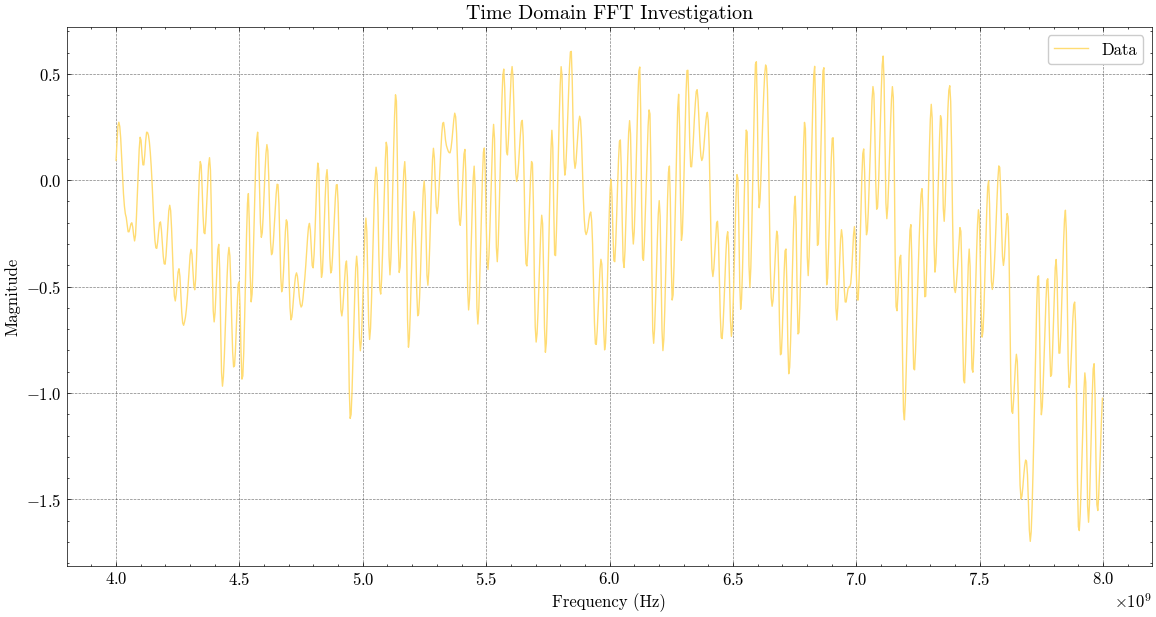

C:\Users\rishi\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\matplotlib\cbook.py:1699: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
C:\Users\rishi\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\matplotlib\cbook.py:1345: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


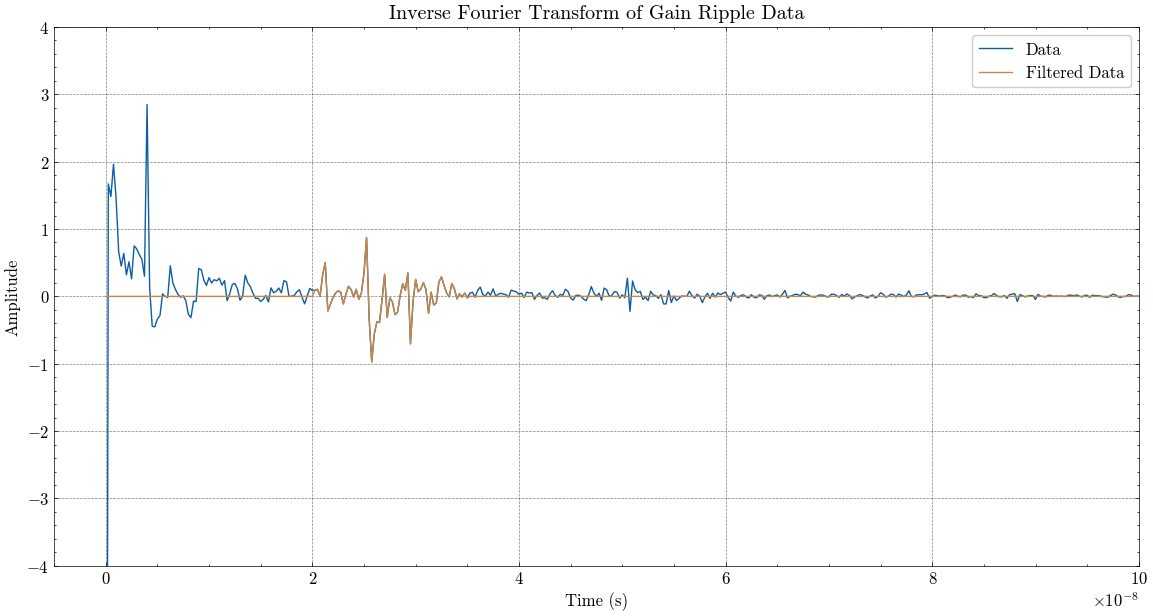

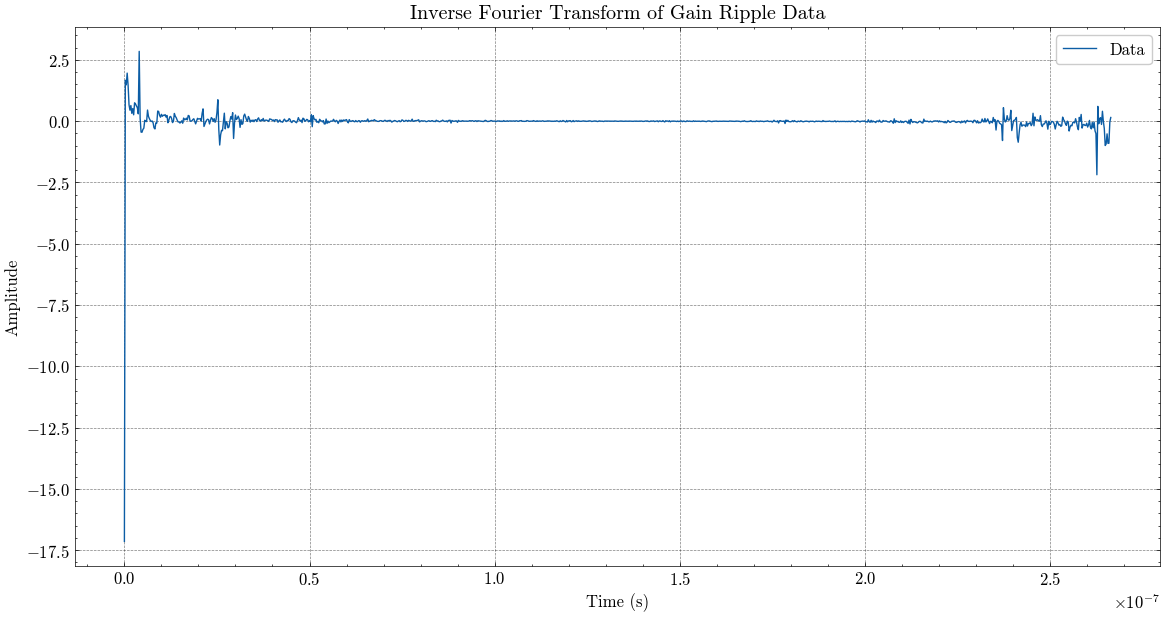

In [4]:
def fourier_transform(filename, csv=False, start_band=4000000000.0, stop_band=8000000000.0, phase=False):
    if (csv == False): 
        file = h5py.File(filename, 'r')
        freq_start = file['Parameters']['VNA_PARAMETERS']['freq_start'][0]
        freq_stop = file['Parameters']['VNA_PARAMETERS']['freq_stop'][0]
        probe_pts = file['Parameters']['VNA_PARAMETERS']['probe_pts'][()]
    
        freqs = np.linspace(freq_start, freq_stop, probe_pts)
        s21 = np.asarray(file['sweep_dataframe']).flatten()    
    else:
        df = pd.read_csv(filename, header=None)
        freqs = df[0].to_numpy()
        s21 = df[1].to_numpy()
        
    mask = (freqs >= start_band) & (freqs <= stop_band)
    freqs_window = freqs[mask]
    s21_window = s21[mask]
    
    # plt.plot(freqs_window, s21_window)
    # if phase == True:
    #     plt.ylabel('S21 Wrapped Phase (Deg)')
    # else:
    #     plt.ylabel('S21 Magnitude (dB)')
    # plt.xlabel('Frequency (Hz)')
    # plt.title('S21 Pump Scans')
    # plt.show()
    
    return freqs_window, s21_window
    
phase = fourier_transform('data/july_data/00825_S21_4to5_10dBattprobe_pumpontopPHAS_7.533e-08_edelay_2.48V_11.978GHz_5.0_dBm_pump.hdf5', phase=True)[1]
freq, mag = fourier_transform('data/july_data/00825_S21_4to5_10dBattprobe_pumpontopMLOG_7.533e-08_edelay_2.33V_11.91GHz_11.0_dBm_pump.hdf5')

## Performing the Inverse Fourier Transform on the Gain Ripple Data ##
def gain_ripple_ifft(mag, freq, phase):
    '''
    #######################################################################
    ### This function takes the magnitude, phase and frequency data     ###
    ### of the gain ripple datasets and turns them first into the       ###
    ### time domain data spectrum using the IFFT that we were looking   ###
    ### for. It also attempts to filter out the 'true' peak and perform ###    
    ### an FFT and plot this back in the original frequency domain      ### 
    ### to look at the true 'gain' of the system without these ripples? ###
    #######################################################################
    '''
    
    phase = np.pi/180 * phase
    full_magdata = mag*np.exp(1j*phase)

    full_magdata_time = ifft(full_magdata)
    
    N = len(freq)
    df = freq[1] - freq[0]
    dt = 1 / (N*df)
    time = np.arange(N) * dt
    
    peaks, _ = find_peaks(full_magdata_time, 2)
    troughs, _ = find_peaks(-full_magdata_time)
    
    mask = np.zeros_like(full_magdata_time)
    mask[(np.where(time >= 2e-8))[0][0] : (np.where(time >= 3.5e-8))[0][0]] = 1
    mask[(np.where(time >= 0))]
    full_magdata_time_peak = full_magdata_time * mask
    
    full_magdata_freq_peak = fft(full_magdata_time_peak)
    full_magdata_freq = fft(full_magdata_time)
    
    plt.plot(freq, phase, label='Data', color='#ffdc73')
    # plt.plot(freq, -np.abs(full_magdata_freq_peak), label='FFT Data Filtered', color='dodgerblue')
    # plt.plot(freq, -np.abs(full_magdata_freq), label='FFTd Data Full')
    plt.title('Time Domain FFT Investigation')
    plt.xlabel('Frequency (Hz)')
    plt.ylabel('Magnitude')
    plt.legend()
    plt.show()
        
    plt.plot(time, full_magdata_time, label='Data')
    plt.plot(time, full_magdata_time_peak, label='Filtered Data', color='peru')
    # plt.plot(time[peaks], full_magdata_time[peaks], 'ro', label='Peaks')
    # plt.plot(time[troughs], full_magdata_time[troughs], 'go', label='Troughs')
    plt.xlabel('Time (s)')
    plt.ylabel('Amplitude')
    plt.title('Inverse Fourier Transform of Gain Ripple Data')
    plt.ylim(-4, 4)
    plt.xlim(-0.05e-7, 1e-7)
    # plt.xlim(4e9, 4.25e9)
    plt.legend()
    plt.show()
    
    plt.plot(time, full_magdata_time, label='Data')
    # plt.plot(time, full_magdata_time_peak, label='Filtered Data', color='peru')
    # plt.plot(time[peaks], full_magdata_time[peaks], 'ro', label='Peaks')
    # plt.plot(time[troughs], full_magdata_time[troughs], 'go', label='Troughs')
    plt.xlabel('Time (s)')
    plt.ylabel('Amplitude')
    plt.title('Inverse Fourier Transform of Gain Ripple Data')
    # plt.ylim(-4, 4)
    # plt.xlim(-0.05e-7, 1e-7)
    # plt.xlim(4e9, 4.25e9)
    plt.legend()
    plt.show()

def gain_ripple_periods(mag, freq, phase):
    '''
    #############################################################################
    ### This function takes the magnitude and frequency of our original       ###  
    ### frequency domain gain ripple data and performs another FFT on it.     ###  
    ### This is done to get the into another time domain and find the peaks   ###  
    ### here which would correspond to the periods of the ripples that we see ###  
    ### back in the frequency domain. Also creates a histogram to portray     ###
    ### these values.                                                         ###
    #############################################################################
    '''
    
    ## Performing a Fourier Transform on the Frequency Domain Data ##
    mag_fft = fft(mag)
    freq_fft = fftfreq(len(freq), (freq[1]-freq[0]))

    plt.plot(freq_fft[freq_fft>=0], np.abs(mag_fft[freq_fft>=0]))
    plt.ylim(0, 1000)
    plt.show()

    phs_fft = fft(phase)
    
    plt.plot(freq_fft[freq_fft>=0], np.abs(phs_fft[freq_fft>=0]))
    plt.ylim(0, 1000)
    plt.show()
    
    ## Since we do a fourier transform on data that is already in the frequency domain, does this mean that
    ## this spectrum is now in units of 1/Hz = seconds? If so, would this mean that these so called 'peaks'
    ## on this spectrum would be the period of the small ripples on it?

    peaks, _ = find_peaks(np.abs(mag_fft[freq_fft>=0]), 100)

    plt.hist(freq_fft[peaks], bins=25, density=True, color='mistyrose', edgecolor='maroon', hatch='///', linewidth=0.2, label='Ripple Periods')
    plt.xlabel('Gain Ripple Periods [s]')
    plt.ylabel('Normalized Counts')
    plt.title('Gain Ripple Period Distribution')
    plt.legend()
    plt.show()

    mag_fft_filtered = np.where(np.abs(mag_fft)>100, mag_fft, 0)
    mag_fft_filtered_ifft = ifft(mag_fft_filtered)

    plt.plot(freq, mag, label='Raw Data', color='#8ec7ff')
    plt.plot(freq, mag_fft_filtered_ifft, label='IFFT Filtered Data', color='firebrick')
    plt.legend()
    plt.ylabel('Magnitude')
    plt.xlabel('Frequency (Hz)')
    plt.show()
    
gain_ripple_ifft(mag, freq, phase)
# gain_ripple_periods(mag, freq, phase)


Bias Current, Pump Power, Pump Frequency. These all create a 3D parameter space, what we want to do is find a region with all of these parameters that are optimized in which we basically see that the device is 'happy'. 'Happy' in this sense implies that there is any sort of gain that is coming from the device. 

Before we continue down the rabbit hole, it is important to know what type of optimization problem we're looking at: 
- Is it static or dynamic? Are we just spanning over the complete parameter space to find ONE fit of the parameters that satisfies our 'output value' that we're attempting to maximize (which would be what exactly?), or are we trying to make a sequence of decisions where each decision is subject to influence from the last? 
- So after talking to Meg, it's sort of static in the sense that for now we're only looking for like a maximum in the parameter space. However, the catch is that there might be different regions in which the gain or some parameter might be 'maximized'. So it's harder than just finding one absolute value, especially since we're not in the ideal TWPA case, there might be multiple 'good/happy' regions that would be of interest. Also the value to maximize is interesting, in the sense that it could be the different values that we've been calculating based on the datasets for a while. Such as, gain ripple amplitude mean/standard deviation, or the integral of the pump on - pump off, or something entirely different that could be a useful value to based this stuff on. I wonder if there's a way to maximize based on multiple variables. 
- Also I want to know how to workflow for this would look like? Like how do I get these datasets and how am I searching across the parameter space?


For Time Domain Reflectrometry stuff I should have to ask Milad for the speed of propagation of the light inside the device so we can use this information along with these 'time' delays to figure out some places inside the device where we could have these impedence or something mismatches. 


In [ ]:
### Testing for Fourier and Inverse Fourier Transform Shennanigans ###

# Generate Data
x = np.linspace(-3, 3, 5000)
y = 0.5*np.sin(2*np.pi*10*x)
for i in range(0, 10):
    y_sin = 0.5*np.sin(2*np.pi*np.random.randint(1, 500)*x)
    y = y + y_sin
noise = 2 * np.random.random(len(x)) - 1
y = y + noise

plt.plot(x, y)
plt.show()

y_fft = fft(y)
x_fft = fftfreq(len(x), (x[1]-x[0]))

plt.plot(x_fft[x_fft>=0], np.abs(y_fft[x_fft>=0]))
plt.show()

peaks, _ = find_peaks(np.abs(y_fft[x_fft>=0]), 1000)
print(x_fft[peaks])

y_fft_filtered = np.where(np.abs(y_fft)>1000, y_fft, 0)
y_fft_filtered_ifft = ifft(y_fft_filtered)

plt.plot(x, y, label='Data')
plt.plot(x, y_fft_filtered_ifft, label='IFFT Data', color='r')
plt.legend()
plt.xlim(-3, -2.5)
plt.show()

Travel time for the cavity if we take the inverse fourier transofrm ion this frequency domain data, what does time mean in this case???? What is the speed of light in this case, talk to Milad, what does this mean? Talk to Meg again about what the hell is going on with this stuff but what does this mean?? 

- At some frequency how effective are we at getting power thru the device, assuming all hardware outside are flat behavior 
- How good are we at getting power thru the TWPA 
- Time space, how good is power at getting through the device?? Time domain reflectometry, at what point in your device, flight time do you see efficiency 
- Photonic crystals, slow light wave guide, expect in the TWPA that the light travels quite slow within it
- How long did it take the light to fly through, consistent behavior for the tramission line. 

Some notes that I got after talking to Milad:
- He expects an underlying signal in our original frequency domain data which is basically the tramission response of the TWPA. Because of mismatches, impedence or otherwise, we get these 'gain ripples' which add noise to this original signal. Essentially what we want to do is perform an IFFT on this data back into the time domain. Here we should expect a very big spike which is basically our original main response from the TWPA, and then a bunch of smaller amplitude 'ripples' which are caused by the same mismatches inside the TWPA. We can then 'gate' that main signal and perform an FFT to get it back to the frequency domain which is the real, I guess sort of response of the TWPA. 
- IDEALLY, we can estimate the sort of placement of these discontinuties within our device based on the time difference between these subsequent ripples. However, this currently cannot be done because we don't have a way to characterize the instruments and connections and stuff that go down to the device. We don't know if these 'ripples' are caused by reflections in the connectors or actually inherent to the device. So needs to be characterized first. Also worthwhile noting that because of some non-linearity, we can expect some weirdish behavior going on that isn't going to be as ideal as the case I basically described. Basically need to see what the hell is going on. 

For now work on code that gets you the FFT and IFFT and test it on a known signal where you can know both the fourier transfom and the inverse fourier transform. 

All this is pretty cool stuff tbh

Looking at the way that the these filters/functions smooth out the data, I've narrowed it down to two that I think would be an appropriate fit given our situation. Either the Savitzky-Golay filter or the Whittaker-Eilers filter sould make good for smoothing these functions. However, there is one main question that needs to be answered when looking at which one of these to choose from. The Whittaker-Eilers function seems to give more local 'curving' and looks at the behavior of the entirety of the dataset. On the other hand the Savitzky-Golay filter seems to be more dependent on the window size and seems to be more 'flat' overall. So do we want something that accounts for the intrisic periodic nature of the dataset or are we content with the smoothing?

We finally ended up choosing the Savitzky-Golay filter to work out this histogram, in the end we wanted to sot of see this flatter more 'consistent' behavior without all of the little ripples. After using this filter, one thing that was immediately apparent was that the smoothed data seemed to hang a lot lower than what was seen on the plot. We thought this was due to weighting initially but it quickly became clear that since those higher 'peaks' were caused by one point and not a lot of data, the filter wasn't obviously weighting these single points higher and so the data overall looked to be lower when smoother out. However, this is no cause for concern because without more clustered data points at these 'peaks' we can't really do much, a.k.a it is an artifact of the data. 

In [ ]:
### Testing Code for Smoothing Functions for Gain Ripple Amplitude Data ###

# Generate Data
x = np.linspace(0, 10, 10000)
y = np.sin(x)
for i in range(0, 10):
    y_sin = np.sin(np.random.randint(1, 100)*x)
    y = y + y_sin
noise = 2 * np.random.random(len(x)) - 1
y = y + noise

# Apply the smoothing function - Savitzky-Golay
smoothed_yS = savgol_filter(y, window_length=100, polyorder=8)

# Apply the smoothing function - Lowess
smoothed_yL = lowess(y, x, frac=0.01, return_sorted=False)

# Apply the smoothing function - Exponential 
data = pd.DataFrame({'x': x, 'y': y})
model = ExponentialSmoothing(data['y'], trend='additive').fit()
smoothed_yE = model.predict(start=1, end=len(data))

# Apply the smoothing function - Whittaker Eilers
smoother = WhittakerSmoother(lmbda=25, order=2, data_length=len(y))
smoothed_yW = smoother.smooth(y)

plt.plot(x, y, label='Data', color='#8ec7ff')
plt.plot(x, smoothed_yS, label='Savitzky-Golay Filter')
# plt.plot(x, smoothed_yL, label='Lowess')
# plt.plot(x, smoothed_yE, label='Exponential Smoothing')
plt.plot(x, smoothed_yW, label='Whittaker Eilers')
plt.title('Random Data Smoothing Functions Test')
plt.legend()
plt.xlim(0, 1)
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Generate some sample data (e.g., from a normal distribution)
data = np.random.normal(loc=0, scale=1, size=1000)

# Create the histogram
hist_counts, bin_edges, _ = plt.hist(data, bins=30, density=True, alpha=0.6, label='Histogram')

# Calculate bin centers for fitting
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

from scipy.optimize import curve_fit

# Define the Gaussian function
def gaussian(x, amplitude, mean, sigma):
    return amplitude * np.exp(-(x - mean)**2 / (2 * sigma**2))

# Provide initial guesses for the parameters (can help with convergence)
initial_guesses = [max(hist_counts), np.mean(data), np.std(data)]

# Perform the curve fitting
popt, pcov = curve_fit(gaussian, bin_centers, hist_counts, p0=initial_guesses)

# Extract the fitted parameters
amplitude_fit, mean_fit, sigma_fit = popt

# Generate the fitted Gaussian curve
x_fit = np.linspace(min(data), max(data), 100)
y_fit = gaussian(x_fit, amplitude_fit, mean_fit, sigma_fit)

# Plot the fitted curve
plt.plot(x_fit, y_fit, 'r-', label='Gaussian Fit')
plt.legend()
plt.title('Gaussian Fit to Histogram')
plt.xlabel('Value')
plt.ylabel('Density')
plt.show()

print(f"Fitted Mean: {mean_fit:.2f}")
print(f"Fitted Standard Deviation: {sigma_fit:.2f}")

In [1]:
df = pd.read_csv('data/august_data/TWPA_2p235mA_5dBm_11.985GHz_PumpOn_Signal_m0dBm_4to8GHz_with_RTamplifier_15dB_front_attenuator.csv', header=None)
frequencies = df[0]
magnitude = df[1]

plt.plot(frequencies, magnitude, label='Data')
plt.show()

def find_ripples_csv(freqs_window, s21_window):    
    peaks, _ = find_peaks(s21_window, prominence=0.0001)
    troughs, _ = find_peaks(-s21_window, prominence=0.0001)
    
    plt.plot(freqs_window, s21_window, label='4-8 GHz Window')
    plt.plot(freqs_window[peaks], s21_window[peaks], 'o', label='Peaks')
    plt.plot(freqs_window[troughs], s21_window[troughs], 'o', label='Troughs')
    plt.title('S21 Pump Scans')
    plt.xlabel('Frequency (Hz)')
    plt.ylabel('S21 Magnitude (dB)')
    plt.xlim(4e9, 4.5e9)
    plt.legend()
    plt.show()  
    
    if len(peaks) >= len(troughs):
        length=len(peaks)
    else:
        length=len(troughs)
        
    peak_first = False
    if freqs_window[peaks[0]] < freqs_window[troughs[0]]:
        peak_first = True
    ripple_amplitudes = []
    for i in range(0, length):
        if (peak_first == True) and ((i+1) < (len(peaks)-1)):
            left_amplitude = s21_window[peaks[i]] - s21_window[troughs[i]]
            right_amplitude = s21_window[peaks[i+1]] - s21_window[troughs[i]]
            amplitude = np.mean([left_amplitude, right_amplitude])
            ripple_amplitudes.append(amplitude/2)
        elif (peak_first == False) and ((i+1) < (len(troughs)-1)):
            left_amplitude = s21_window[peaks[i]] - s21_window[troughs[i]]
            right_amplitude = s21_window[peaks[i]] - s21_window[troughs[i+1]]
            amplitude = np.mean([left_amplitude, right_amplitude])
            ripple_amplitudes.append(amplitude/2)
        else:
            break
    
    return ripple_amplitudes

ripple_hist(
    
)

def rolling_avg(filename):
    file = h5py.File(filename, 'r')
    freq_start = file['Parameters']['VNA_PARAMETERS']['freq_start'][0]
    freq_stop = file['Parameters']['VNA_PARAMETERS']['freq_stop'][0]
    probe_pts = file['Parameters']['VNA_PARAMETERS']['probe_pts'][()]
    
    freqs = np.linspace(freq_start, freq_stop, probe_pts)
    s21 = np.asarray(file['sweep_dataframe']).flatten()    
    mask = (freqs >= freq_start) & (freqs <= 8000000000.0)
    
    freqs_window = freqs[mask]
    s21_window = s21[mask]
    
    df = pd.DataFrame({'Frequency': freqs_window, 'Magnitude': s21_window})
    s21_ravg = (df.Magnitude.rolling(25).mean()).to_numpy()
    
    plt.plot(freqs_window, s21_window, label='S21 Magnitude Data', color='#8ec7ff')
    plt.plot(freqs_window, s21_ravg, label='Rolling Average', color='#1e90ff')
    plt.title('S21 Pump Scans')
    plt.xlabel('Frequency (Hz)')
    plt.ylabel('S21 Magnitude (dB)')
    # plt.xlim(4e9, 4.5e9)
    plt.legend()
    plt.show()

        # if (peak_first == True) and ((i+1) < (len(peaks)-1)):
        #     left_amplitude = s21_window[peaks[i]] - s21_window[troughs[i]]
        #     right_amplitude = s21_window[peaks[i+1]] - s21_window[troughs[i]]
        #     amplitude = np.mean([left_amplitude, right_amplitude])
        #     ripple_amplitudes.append(amplitude/2)
        # elif (peak_first == False) and ((i+1) < (len(troughs)-1)):
        #     left_amplitude = s21_window[peaks[i]] - s21_window[troughs[i]]
        #     right_amplitude = s21_window[peaks[i]] - s21_window[troughs[i+1]]
        #     amplitude = np.mean([left_amplitude, right_amplitude])
        #     ripple_amplitudes.append(amplitude/2)
        # else:
        #     break
        
if len(peaks) >= len(troughs):
    #     length=len(peaks)
    # else:
    #     length=len(troughs)
        
    # peak_first = False
    # if freqs_window[peaks[0]] < freqs_window[troughs[0]]:
    #     peak_first = True

SyntaxError: incomplete input (2444660706.py, line 96)

The code above is working on measuring the amplitudes of the gain ripples that we see, specifically within the 4-8 GHz bandwidth. I'm trying to get sort of a histogram distribution of how many gain ripples we see in each sort of plot of the S21 Magnitude versus the Frequency that we're sweeping across. The code below is working on the quantity that we want to get for each dataset that will give a more quantitative approach to figuring out how much gain we're seeing. It'll take the difference of the gain from the pump on - pump off and integrate across the entire desired bandwidth within 4-8 GHz. 

When looking at the NIST plots for the histograms, why are there negative dB amplitudes? What constitutes a negative amplitude, is it based off of their modelled gain that they seem to plot overtop the entirety of the data?? Also when looking at bin sizes for the histogram, would the ideal number of bins just be the default? Which gives results that are the most comprehensible??

Smoothing the data, and looking into calculating these values again to see if there are any differences.


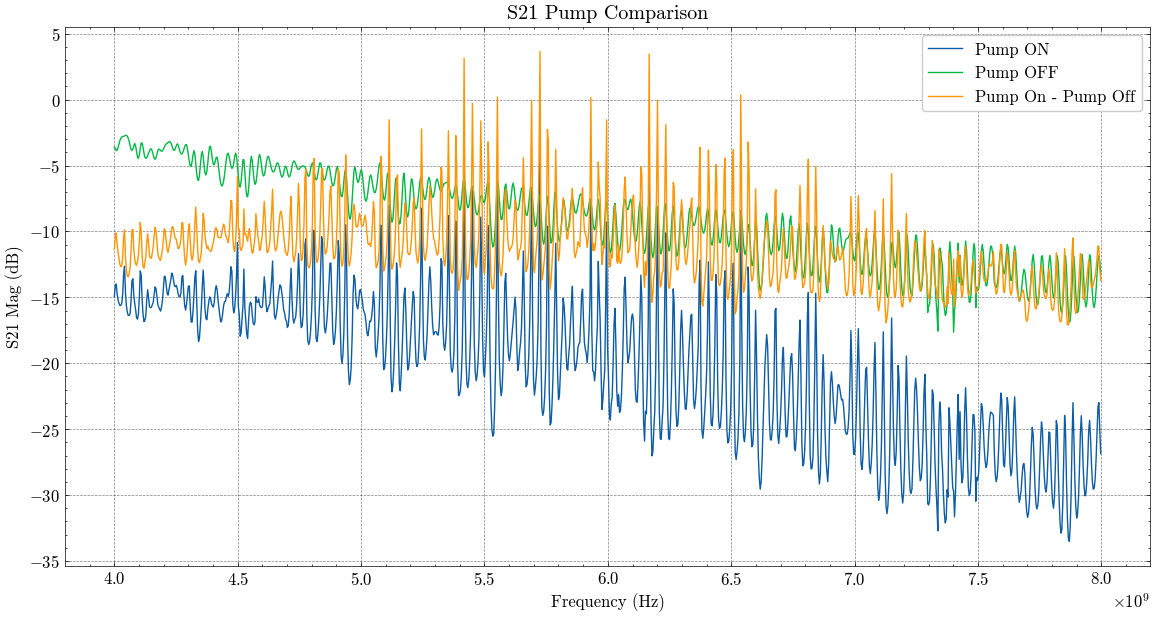

np.float64(-45148403252.36371)

In [11]:
def pump_comparison(filename_pumpon, filename_pumpoff):
    pumpon = h5py.File(filename_pumpon, 'r')
    freq_start_on = pumpon['Parameters']['VNA_PARAMETERS']['freq_start'][0]
    freq_stop_on = pumpon['Parameters']['VNA_PARAMETERS']['freq_stop'][0]
    probe_pts_on = pumpon['Parameters']['VNA_PARAMETERS']['probe_pts'][()]

    freqs_on = np.linspace(freq_start_on, freq_stop_on, probe_pts_on)
    s21_on = np.asarray(pumpon['sweep_dataframe']).flatten()
    
    pumpoff = h5py.File(filename_pumpoff, 'r')
    freq_start_off = pumpoff['Parameters']['VNA_PARAMETERS']['freq_start'][0]
    freq_stop_off = pumpoff['Parameters']['VNA_PARAMETERS']['freq_stop'][0]
    probe_pts_off = pumpoff['Parameters']['VNA_PARAMETERS']['probe_pts'][()]

    freqs_off = np.linspace(freq_start_off, freq_stop_off, probe_pts_off)
    s21_off = np.asarray(pumpoff['sweep_dataframe']).flatten()

    # plt.plot(freqs_on, s21_on, label='Pump ON')
    # plt.plot(freqs_off, s21_off, label='Pump OFF')
    # plt.title('S21 Pump Scans')
    # plt.xlabel('Frequency (Hz)')
    # plt.ylabel('S21 Magnitude (dB)')
    # plt.legend()
    # plt.show()
    
    mask = (freqs_on >= freq_start_on) & (freqs_on <= 8000000000.0)
    
    return [freqs_on, s21_on, freqs_off, s21_off, mask]

def gain_quantity(params):
    freqo = params[0][params[4]]
    s21o = params[1][params[4]]
    freqf = params[2][params[4]]
    s21f = params[3][params[4]]
    gain = s21o - s21f
    
    plt.plot(freqo, s21o, label='Pump ON')
    plt.plot(freqf, s21f, label='Pump OFF')
    plt.plot(freqo, s21o-s21f, label='Pump On - Pump Off')
    # plt.plot(freqo, gain, label='Pump ON - Pump OFF')
    plt.title('S21 Pump Comparison')
    plt.xlabel('Frequency (Hz)')
    plt.ylabel('S21 Mag (dB)')
    plt.legend()
    plt.show()   
    
    return integrate.simpson(gain, x=freqo)
    
gain_quantity(
    pump_comparison(
        'data/july_data/01427_S21_4to5_10dBattprobe_pumpontopMLOG_7.533e-08_edelay_2.28V_11.925GHz_9.4_dBm_pump.hdf5',
        'data/july_data/01426_S21_4to5_10dBattprobe_pumpontopMLOG_7.533e-08_edelay_2.28V_11.925GHz_9.4_dBm_pump_PUMP_OFF.hdf5'
    )
)



In [ ]:
file = h5py.File('full_july_data/00001_S21_4to5_10dBattprobe_pumpontopMLOG_7.533e-08_edelay_2.2V_11.95GHz_7.0_dBm_pump_PUMP_OFF.hdf5', 'r')
pump_on = (file['Parameters']['EQUIPMENT_PARAMETERS']['pump_on'][()])
measurement = ((file['Parameters']['VNA_PARAMETERS']['measurement_type'][()]).decode('utf-8'))

for 


- Why does some of the plots for the pump on versus pump off show that the pump OFF has a higher reading, shouldn't it be the other way around?

In [ ]:
import pandas as pd

df = pd.read_csv('data/pumpon_11p985GHz_5p8dBm_2p25V_ibias_5p35GHz_signal_SA.csv', header=None)

plt.plot(df[0].to_numpy(), df[1].to_numpy())
plt.xlabel('Frequency (Hz)')
plt.ylabel('S21 Magnitude (dB)')
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Example: generate a signal
t = np.linspace(0, 1, 500, endpoint=False)   # time array (1 second sampled at 500 Hz)
freq1, freq2 = 50, 120                       # frequencies in Hz
signal = np.sin(2*np.pi*freq1*t) + 0.5*np.sin(2*np.pi*freq2*t)

# Perform Fourier Transform
fft_vals = np.fft.fft(signal)         # complex numbers
fft_freqs = np.fft.fftfreq(len(signal), d=t[1]-t[0])  # frequencies corresponding to fft_vals

# Take only the positive half (since FFT is symmetric for real signals)
pos_mask = fft_freqs >= 0
fft_freqs = fft_freqs[pos_mask]
fft_vals = np.abs(fft_vals[pos_mask])  # magnitude

# Plot
plt.plot(fft_freqs, fft_vals)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Amplitude")
plt.title("FFT of signal")
plt.show()

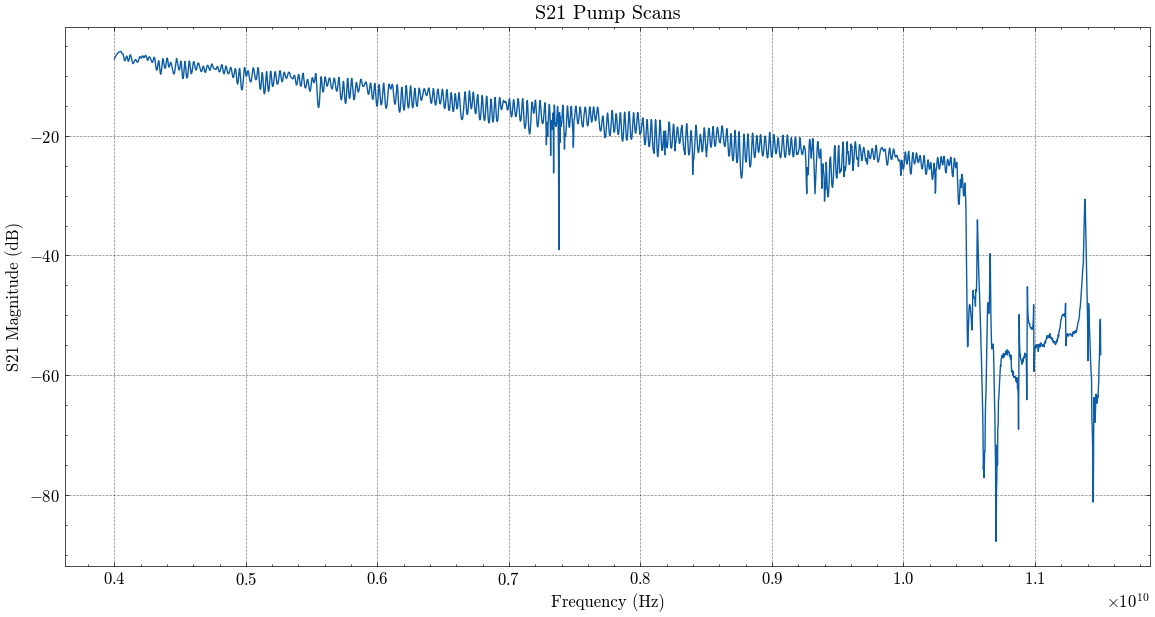

In [5]:
def gain_ripple_plotting(filename) :
    file = h5py.File(filename, 'r')
    freq_start = file['Parameters']['VNA_PARAMETERS']['freq_start'][0]
    freq_stop = file['Parameters']['VNA_PARAMETERS']['freq_stop'][0]
    probe_pts = file['Parameters']['VNA_PARAMETERS']['probe_pts'][()]

    freqs = np.linspace(freq_start, freq_stop, probe_pts)
    s21 = np.asarray(file['sweep_dataframe']).flatten()

    plt.plot(freqs, s21)
    plt.title('S21 Pump Scans')
    plt.xlabel('Frequency (Hz)')
    plt.ylabel('S21 Magnitude (dB)')
    plt.show()

gain_ripple_plotting('data/datafiles_05232025/03637_S21_4to5_10dBatten_splitter_biasscanMLOG_8.4875e-08_edelay_1.7V_12.87GHz_12_dBm_pump.hdf5')

def gain_fourier(filename):
    file = h5py.File(filename, 'r')
    freq_start = file['Parameters']['VNA_PARAMETERS']['freq_start'][0]
    freq_stop = file['Parameters']['VNA_PARAMETERS']['freq_stop'][0]
    probe_pts = file['Parameters']['VNA_PARAMETERS']['probe_pts'][()]
    
    print(freq_start, freq_stop)

    freqs = np.linspace(freq_start, freq_stop, probe_pts)
    s21 = np.asarray(file['sweep_dataframe']).flatten()    
    mask = (freqs >= freq_start) & (freqs <= 8000000000.0)
    
    freqs_window = freqs[mask]
    s21_window = s21[mask]
    
    plt.plot(freqs_window, s21_window, label='4-8 GHz Window')
    plt.title('S21 Pump Scans')
    plt.xlabel('Frequency (Hz)')
    plt.ylabel('S21 Magnitude (dB)')
    plt.legend()
    plt.show()
    
    fourier_transform = np.fft.ifft(s21_window)  
    df = freqs_window[1] - freqs_window[0]              # frequency step
    time = np.fft.fftfreq(len(s21_window), d=df)        # time axis (s)

    # Plot magnitude of transform
    plt.plot(time*1e9, np.abs(fourier_transform))
    plt.xlabel("Time (ns)")
    plt.ylabel("Impulse response")
    plt.title("Time-domain response (from ripple in frequency domain)")
    plt.xlim(2, 20)  # zoom in on positive times
    plt.ylim(0, 0.5)
    plt.show()


M12 5 Pin Connector Side (Power Supply)
Pin 1 - Brn -- Vd
Pin 2 - Blk 
Pin 3 - Ora
Pin 4 - Red -- Vg
Pin 5 - Yel -- GND

M12 3 Pin Connector Side (Breakout Box)
Pin 1 -- Brn -- Vd
Pin 2 -- Yel -- GND
Pin 3 -- Red -- Vg